In [1]:
import numpy as np
import plotly.graph_objects as go
import os

def visualize_scene_interactive(npz_path: str):
    if not os.path.exists(npz_path):
        print(f"File not found: {npz_path}")
        return

    # Load data
    data = np.load(npz_path)
    entity_vertices = data['entity_vertices']      # [N, 2048, 3]
    entity_materials = data['entity_materials']    # [N, 10]
    num_objects = data['num_objects']

    print(f"Loaded {num_objects} objects from {npz_path}")

    fig = go.Figure()

    # Plot each object as a separate trace
    for i in range(num_objects):
        points = entity_vertices[i]
        
        # Extract diffuse color
        diffuse_color = entity_materials[i, 0:3]
        
        # Handle pure black / emissive visibility
        if np.all(diffuse_color == 0):
            color_vec = entity_materials[i, 6:9] # Fallback to emissive
        else:
            color_vec = diffuse_color
            
        # Convert to 0-255 RGB string for Plotly
        r, g, b = np.clip(color_vec * 255, 0, 255).astype(int)
        color_str = f'rgb({r}, {g}, {b})'
        
        fig.add_trace(go.Scatter3d(
            x=points[:, 0],
            y=points[:, 1],
            z=points[:, 2],
            mode='markers',
            marker=dict(
                size=2,
                color=color_str,
                opacity=0.8
            ),
            name=f'Object {i}'
        ))

    # Make axes scale equally and set boundaries
    fig.update_layout(
        scene=dict(
            aspectmode='data', # Ensures the 3D space isn't stretched
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z'
        ),
        title=f"Scene Topology: {os.path.basename(npz_path)}",
        margin=dict(l=0, r=0, b=0, t=40) # Reduce whitespace
    )
    
    fig.show()


In [ ]:

npz_path = "/home/sazhang/Neural-Radiosity-Renderer/data_generation/output_auto/datasets/attempt3_fixed_view_table/case_002_04379243_e2e3f057399a2b41276b6f6d90ee3a83_c0_r0.npz"
visualize_scene_interactive(npz_path)

In [2]:
import matplotlib.pyplot as plt

def visualize_radiance_distribution(exr_path: str, bins: int = 200, log_hist: bool = True):
    """Plot radiance value distributions from an EXR to inspect outliers."""
    if not os.path.exists(exr_path):
        print(f"File not found: {exr_path}")
        return

    img = None
    # Try Mitsuba first (keeps HDR)
    try:
        import mitsuba as mi
        mi.set_variant('scalar_rgb')
        bmp = mi.Bitmap(exr_path)
        img = np.array(bmp, dtype=np.float32)
    except Exception:
        pass

    # Fallback: imageio
    if img is None:
        try:
            import imageio.v3 as iio
            img = iio.imread(exr_path).astype(np.float32)
        except Exception as e:
            print(f"Failed to load EXR: {e}")
            return

    # Ensure shape is HxWxC
    if img.ndim == 2:
        img = img[..., None]
    if img.shape[-1] > 3:
        img = img[..., :3]

    vals = img.reshape(-1, img.shape[-1])
    luminance = 0.2126 * vals[:, 0] + 0.7152 * vals[:, 1] + 0.0722 * vals[:, 2]

    def _print_stats(name, arr):
        p = np.percentile(arr, [0, 50, 90, 99, 99.9, 100])
        print(f"{name} stats: min={p[0]:.4e}, p50={p[1]:.4e}, p90={p[2]:.4e}, "
              f"p99={p[3]:.4e}, p99.9={p[4]:.4e}, max={p[5]:.4e}")

    _print_stats("Luminance", luminance)

    plt.figure(figsize=(8, 4))
    plt.hist(luminance, bins=bins, color='steelblue')
    plt.title("Luminance distribution (linear)")
    plt.xlabel("Radiance")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    if log_hist:
        safe = np.clip(luminance, 1e-8, None)
        plt.figure(figsize=(8, 4))
        plt.hist(np.log10(safe), bins=bins, color='tomato')
        plt.title("Luminance distribution (log10)")
        plt.xlabel("log10(Radiance)")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

mkdir -p failed for path /afs/csail.mit.edu/u/s/sazhang/.config/matplotlib: [Errno 13] Permission denied: '/afs/csail.mit.edu/u/s/sazhang/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-0jcefwt0 because there was an issue with the default path (/afs/csail.mit.edu/u/s/sazhang/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Luminance stats: min=2.7113e-10, p50=3.3596e-01, p90=8.5499e-01, p99=3.0173e+01, p99.9=3.0541e+01, max=3.0566e+01


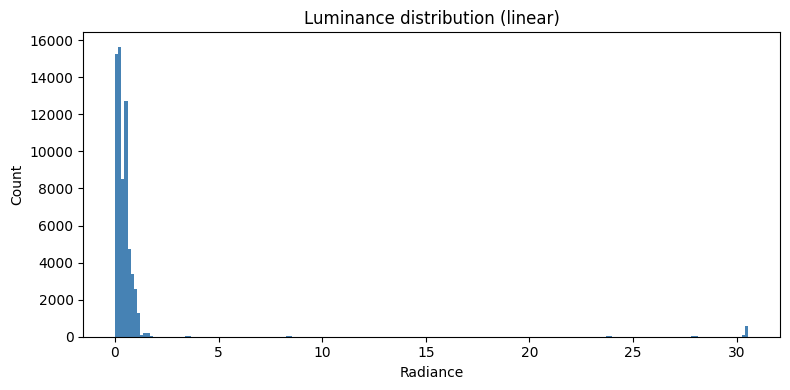

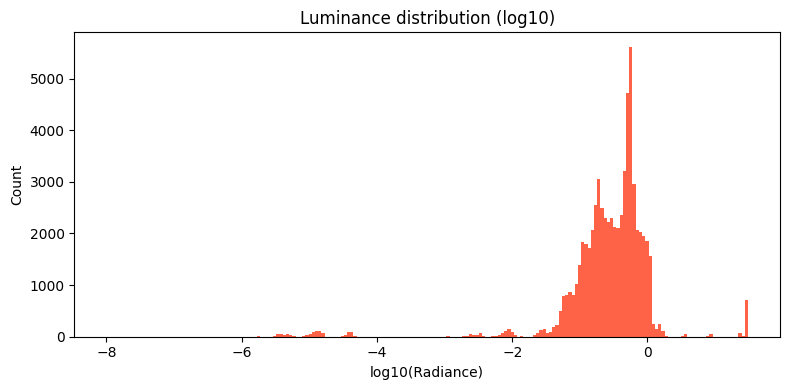

In [4]:
exr_path = "/home/sazhang/Neural-Radiosity-Renderer/data_generation/output_auto/datasets/attempt3_fixed_view_table/case_002_04379243_e2e3f057399a2b41276b6f6d90ee3a83_c0_r0_render.exr"
visualize_radiance_distribution(exr_path)

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_radiance_raw_distribution(exr_path: str, bins: int = 200, log_hist: bool = True):
    """Plot raw radiance distributions (no luminance weighting)."""
    if not os.path.exists(exr_path):
        print(f"File not found: {exr_path}")
        return

    img = None
    # Try Mitsuba first (keeps HDR)
    try:
        import mitsuba as mi
        mi.set_variant('scalar_rgb')
        bmp = mi.Bitmap(exr_path)
        img = np.array(bmp, dtype=np.float32)
    except Exception:
        pass

    # Fallback: imageio
    if img is None:
        try:
            import imageio.v3 as iio
            img = iio.imread(exr_path).astype(np.float32)
        except Exception as e:
            print(f"Failed to load EXR: {e}")
            return

    # Ensure shape is HxWxC
    if img.ndim == 2:
        img = img[..., None]
    if img.shape[-1] > 3:
        img = img[..., :3]

    vals = img.reshape(-1, img.shape[-1])
    pooled = vals.reshape(-1)  # all channels pooled
    per_pixel_max = vals.max(axis=1)
    per_pixel_mean = vals.mean(axis=1)

    def _print_stats(name, arr):
        p = np.percentile(arr, [0, 50, 90, 99, 99.9, 100])
        print(f"{name} stats: min={p[0]:.4e}, p50={p[1]:.4e}, p90={p[2]:.4e}, "
              f"p99={p[3]:.4e}, p99.9={p[4]:.4e}, max={p[5]:.4e}")

    _print_stats("RGB pooled", pooled)
    _print_stats("Per-pixel max", per_pixel_max)
    _print_stats("Per-pixel mean", per_pixel_mean)

    # Pooled RGB
    plt.figure(figsize=(8, 4))
    plt.hist(pooled, bins=bins, color='steelblue')
    plt.title("RGB pooled distribution (linear)")
    plt.xlabel("Radiance")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    # Per-channel
    plt.figure(figsize=(8, 4))
    plt.hist(vals[:, 0], bins=bins, alpha=0.6, label="R")
    plt.hist(vals[:, 1], bins=bins, alpha=0.6, label="G")
    plt.hist(vals[:, 2], bins=bins, alpha=0.6, label="B")
    plt.title("Per-channel distribution (linear)")
    plt.xlabel("Radiance")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Per-pixel max/mean
    plt.figure(figsize=(8, 4))
    plt.hist(per_pixel_max, bins=bins, alpha=0.6, label="per-pixel max")
    plt.hist(per_pixel_mean, bins=bins, alpha=0.6, label="per-pixel mean")
    plt.title("Per-pixel max/mean (linear)")
    plt.xlabel("Radiance")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

    if log_hist:
        safe = np.clip(pooled, 1e-8, None)
        plt.figure(figsize=(8, 4))
        plt.hist(np.log10(safe), bins=bins, color='tomato')
        plt.title("RGB pooled distribution (log10)")
        plt.xlabel("log10(Radiance)")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()


RGB pooled stats: min=6.9040e-11, p50=3.2678e-01, p90=8.3448e-01, p99=3.0037e+01, p99.9=3.0674e+01, max=3.0767e+01
Per-pixel max stats: min=6.3047e-10, p50=5.1719e-01, p90=9.4464e-01, p99=3.0307e+01, p99.9=3.0714e+01, max=3.0767e+01
Per-pixel mean stats: min=3.0266e-10, p50=2.6109e-01, p90=8.1886e-01, p99=3.0122e+01, p99.9=3.0479e+01, max=3.0505e+01


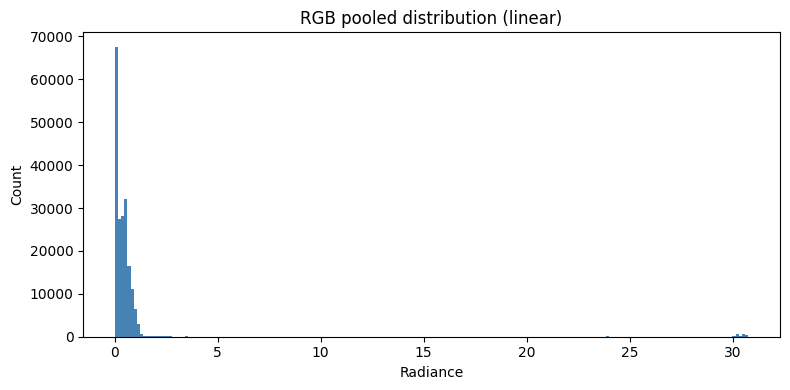

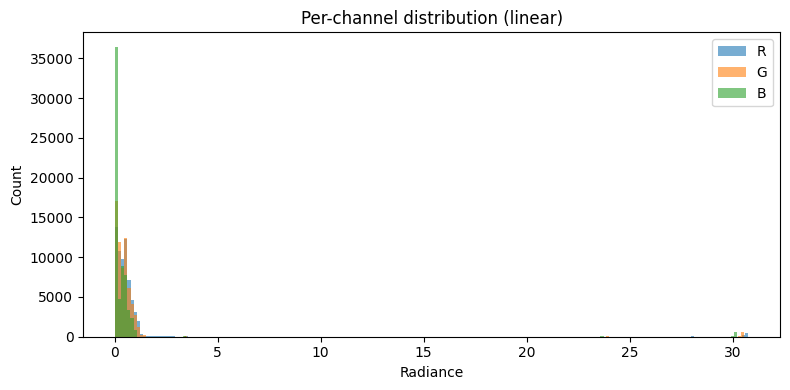

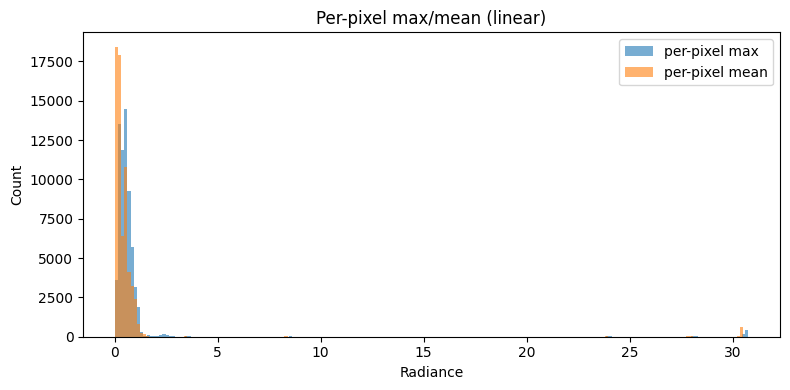

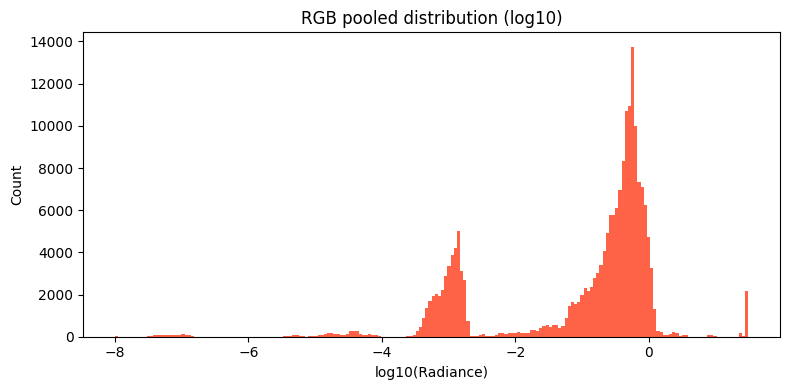

In [6]:
visualize_radiance_raw_distribution(exr_path)